In [2]:
import torch
import numpy as np
from torch import nn
from matplotlib import pyplot as plt

In [3]:
# Tensor is a generalized multi dimensional array
# Tensor if the fundamental data structure in PyTorch
# Input output, weight and gradient are all tensors

# Dimensions
d0 = torch.tensor(3.14)
print(d0, d0.ndim)  # 0
d1 = torch.tensor([3.14, 2.71, 1.62])
print(d1, d1.ndim)  # 1
d2 = torch.tensor([[3.14, 2.71, 1.62], [1.41, 1.73, 2.23]])
print(d2, d2.ndim)  # 2
d3 = torch.tensor([[[3.14, 2.71, 1.62], [1.41, 1.73, 2.23]], [[0.11, 0.22, 0.33], [0.44, 0.55, 0.66]]])
print(d3, d3.ndim)  # 3

tensor(3.1400) 0
tensor([3.1400, 2.7100, 1.6200]) 1
tensor([[3.1400, 2.7100, 1.6200],
        [1.4100, 1.7300, 2.2300]]) 2
tensor([[[3.1400, 2.7100, 1.6200],
         [1.4100, 1.7300, 2.2300]],

        [[0.1100, 0.2200, 0.3300],
         [0.4400, 0.5500, 0.6600]]]) 3


In [4]:
# Creating tensors
a = torch.tensor([1, 2, 3], dtype=torch.float32)
print(a, a.dtype)  # 1
b = torch.zeros((2, 3), dtype=torch.float32)
print(b, b.dtype)  # 2
c = torch.rand((2, 3), dtype=torch.float32)
print(c, c.dtype)  # 3
print(c.shape, c.device)

tensor([1., 2., 3.]) torch.float32
tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.float32
tensor([[0.6255, 0.9533, 0.1233],
        [0.9782, 0.6336, 0.8349]]) torch.float32
torch.Size([2, 3]) cpu


In [5]:
# Operations on a tensor
a = torch.tensor([[1, 2, 3],[4,5,6]], dtype=torch.float32)
print(a.ndim, a.shape)  # 2, (2,3)
print(a*a, a+a)
print(a@a.T)

2 torch.Size([2, 3])
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]]) tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])
tensor([[14., 32.],
        [32., 77.]])


In [6]:
# Numpy arrays and Pytorch tensors are interchangeable
n = np.array([[1, 2, 3],[4,5,6]])
t = torch.from_numpy(n)  # Convert numpy array to torch tensor
print(t, t.dtype)
n1 = t.numpy()  # Convert torch tensor to numpy array
print(n1, n1.dtype)
n1+=5
print(n1, n1.dtype)
print(t, t.dtype)  # The torch tensor is also updated

tensor([[1, 2, 3],
        [4, 5, 6]]) torch.int64
[[1 2 3]
 [4 5 6]] int64
[[ 6  7  8]
 [ 9 10 11]] int64
tensor([[ 6,  7,  8],
        [ 9, 10, 11]]) torch.int64


In [7]:
## Computational graph
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
z = w * x + b #7
y = z ** 2 # 49
print(y)
y.backward()  # Compute gradients - Autograd
print(x.grad, w.grad, b.grad)  # 28.0, 14.0, 7.0

tensor(49., grad_fn=<PowBackward0>)
tensor(42.) tensor(28.) tensor(14.)


In [8]:
w = torch.tensor(3.0, requires_grad=True)
for i in range(3):
    loss =  (w*2.0 - 4.0)**2
    loss.backward()
    print(w.grad)
    w.grad.zero_()  # Reset gradients to zero before next iteration

tensor(8.)
tensor(8.)
tensor(8.)


In [9]:
## Factory functions to create tensors
a = torch.zeros((2, 3), dtype=torch.float32)
print(a, a.dtype)  # 2
b = torch.ones((2, 3), dtype=torch.float32)
print(b, b.dtype)  # 2
c = torch.eye(3)
print(c, c.dtype)  # 2
d = torch.randn((2, 3), dtype=torch.float32)
print(d, d.dtype)  # 2
e = torch.arange(0, 10, 2)
print(e, e.dtype)  # 2
x = torch.rand(2,3)
print(x, x.dtype)  # 2
y = torch.zeros_like(x)
print(y, y.dtype)  # 2
z = torch.ones_like(x)
print(z, z.dtype)  # 2
k = torch.empty((2, 3), dtype=torch.float32)
print(k, k.dtype)  # 2  
l = torch.empty_like(x)
print(l, l.dtype)  # 2
m = torch.rand_like(x)
print(m, m.dtype)  # 2

tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.float32
tensor([[1., 1., 1.],
        [1., 1., 1.]]) torch.float32
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]) torch.float32
tensor([[-0.6161, -0.6444, -0.5909],
        [-0.5151, -1.1719, -0.3555]]) torch.float32
tensor([0, 2, 4, 6, 8]) torch.int64
tensor([[0.3227, 0.4623, 0.8973],
        [0.0018, 0.4342, 0.0475]]) torch.float32
tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.float32
tensor([[1., 1., 1.],
        [1., 1., 1.]]) torch.float32
tensor([[2.8166e-22, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 4.4842e-44, 0.0000e+00]]) torch.float32
tensor([[3.5967e-22, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00]]) torch.float32
tensor([[0.4747, 0.1102, 0.6216],
        [0.1630, 0.4014, 0.2624]]) torch.float32


In [10]:
## Indexing and slicing
a = torch.tensor([[1, 2, 3],[4,5,6]], dtype=torch.float32)
print(a.shape, a.ndim)  # 2, (2,3)
print(a[0:2, 0:2])  # 2x2
print(a[:,0])  # 2x1
a = a.reshape(3,2)  # Reshape to 3x2
print(a)  # 3x2
print(a.flatten())  # Flatten to 1D

torch.Size([2, 3]) 2
tensor([[1., 2.],
        [4., 5.]])
tensor([1., 4.])
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([1., 2., 3., 4., 5., 6.])


In [11]:
# Q1. Create a 3×3 tensor filled with random values between 0 and 1, 
# and normalize it so all entries sum to 1. 
x = torch.rand(3,3)
print(x, x.sum()) 
x_norm = x/x.sum()
print(x_norm, x_norm.sum())

tensor([[0.0733, 0.4019, 0.7188],
        [0.7342, 0.6802, 0.2440],
        [0.7237, 0.0749, 0.4528]]) tensor(4.1039)
tensor([[0.0179, 0.0979, 0.1751],
        [0.1789, 0.1658, 0.0595],
        [0.1763, 0.0183, 0.1103]]) tensor(1.0000)


In [12]:
# Q2. Reshape a 1D tensor of length 16 
# into a 4×4 matrix, then flatten it back. 
x = torch.arange(16)
print(x,x.shape)
x = x.reshape(4,4)
print(x)
x = x.flatten()
print(x)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]) torch.Size([16])
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])


In [13]:
# Q3. Multiply two tensors (size 3×4 and 4×2) 
# and verify the output shape.  
x = torch.arange(12).view(3,4)
y = torch.arange(8).view(4,2)
print(x,y)
print(x@y)
print(torch.matmul(x,y))

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]) tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7]])
tensor([[ 28,  34],
        [ 76,  98],
        [124, 162]])
tensor([[ 28,  34],
        [ 76,  98],
        [124, 162]])


In [14]:
# Define a scalar function f(x) = x^2 + 3x 
# Compute the gradient at (x=2) using autograd. 
x = torch.tensor(2.0, requires_grad=True)
f = x**2 + 3*x
# Compute the gradient using .backward()
f.backward()
print(x, x.grad.item())

tensor(2., requires_grad=True) 7.0


In [15]:
# Define a scalar function f(x) = (x^2 + 3x)^3 
# Compute the gradient at (x=2) using autograd.
x = torch.tensor(2.0, requires_grad=True)
f = (x**2 + 3*x)**3
# Compute the gradient using .backward()
f.backward()
print(x, x.grad.item())

tensor(2., requires_grad=True) 2100.0


In [16]:
# Define a scalar function f(x,y) = (x^2 *y + 3xy**2)**2 
# Compute the gradient at (x=2, y=3) using autograd.
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
f = (x**2*y+3*x*y**2)**2
# compute gradient using .backward()
f.backward()
print(x,x.grad.item())
print(y,y.grad.item())

tensor(2., requires_grad=True) 5148.0
tensor(3., requires_grad=True) 5280.0


In [17]:
# Create a tensor with `requires_grad=True`, perform operations, 
# and stop gradient tracking midway using `torch.no_grad()`.
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x

with torch.no_grad():
    z = y*5   
    
y.backward()
print(x.grad.item())

7.0


In [18]:
# Implement Mean Absolute Error (MAE) manually 
# and compare with nn.L1Loss
x = torch.tensor([[1.0],[2.0],[3.0],[4.0]])
y = torch.tensor([[7.0],[9.0],[11.0],[13.0]])
print(x,y)
# y = m.x + c
model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.L1Loss()
model.weight = nn.Parameter(torch.tensor([[1.0]]))
model.bias = nn.Parameter(torch.tensor([3.0]))
y_pred = model(x)
loss = loss_fn(y,y_pred)
print(loss)
print(loss.item()==4.5)

tensor([[1.],
        [2.],
        [3.],
        [4.]]) tensor([[ 7.],
        [ 9.],
        [11.],
        [13.]])
tensor(4.5000, grad_fn=<MeanBackward0>)
True


In [ ]:
#question 7

import torch
import torch.nn as nn
 
# Synthetic data
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])
 
# Linear Regression Model
model = nn.Linear(1, 1)
 
# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
 
# Training
for epoch in range(100):
    pred = model(X)
    loss = criterion(pred, y)
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
print("Weight:", model.weight)
print("Bias:", model.bias)

Weight: Parameter containing:
tensor([[1.8872]], requires_grad=True)
Bias: Parameter containing:
tensor([0.3318], requires_grad=True)


In [ ]:
#question 8
import torch
import torch.nn as nn
 
# Model
model = nn.Linear(1, 1)
 
# Sample Data
X = torch.tensor([[1.0], [2.0], [3.0]])
y = torch.tensor([[2.0], [4.0], [6.0]])
 
# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
 
# Training Loop
for epoch in range(10):
 
    # Forward Pass
    output = model(X)
 
    # Compute Loss
    loss = criterion(output, y)
 
    # Backward Pass
    optimizer.zero_grad()
    loss.backward()
 
    # Update Weights
    optimizer.step()
 
    print(f"Epoch {epoch+1}, Loss = {loss.item()}")

Epoch 1, Loss = 31.48283576965332
Epoch 2, Loss = 24.932199478149414
Epoch 3, Loss = 19.754053115844727
Epoch 4, Loss = 15.660780906677246
Epoch 5, Loss = 12.425044059753418
Epoch 6, Loss = 9.867146492004395
Epoch 7, Loss = 7.845045566558838
Epoch 8, Loss = 6.246463775634766
Epoch 9, Loss = 4.98265266418457
Epoch 10, Loss = 3.9834606647491455


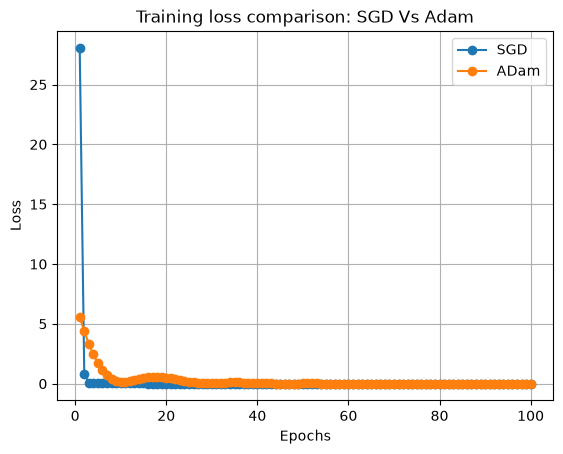

In [19]:
# Train a model with both SGD and Adam optimizers, 
# compare convergence speed.
# forward pass and compute the predicted value
# compute the loss
# backward propogation to compute the gradients
# Optimize
x_SGD = torch.tensor([[0.],[1.],[2.],[3.]])     
y_SGD = torch.tensor([[1.],[3.],[5.],[7.]])
x_Adam = torch.tensor([[0.],[1.],[2.],[3.]])     
y_Adam = torch.tensor([[1.],[3.],[5.],[7.]])

model_SGD = nn.Linear(in_features=1, out_features=1)
model_Adam = nn.Linear(in_features=1, out_features=1)

loss_fn_SGD = nn.MSELoss()
loss_fn_Adam = nn.MSELoss()

optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr = 0.1)
optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr = 0.1)

losses_SGD = []
losses_Adam = []

for epoch in range(100):
    y_pred_SGD = model_SGD(x_SGD)
    loss_SGD = loss_fn_SGD(y_pred_SGD, y_SGD)
    losses_SGD.append(loss_SGD.item())
    model_SGD.zero_grad()
    loss_SGD.backward()
    optimizer_SGD.step()

    y_pred_Adam = model_Adam(x_Adam)
    loss_Adam = loss_fn_Adam(y_pred_Adam, y_Adam)
    losses_Adam.append(loss_Adam.item())
    model_Adam.zero_grad()
    loss_Adam.backward()
    optimizer_Adam.step()

epochs = range(1,len(losses_SGD)+1)
plt.plot(epochs, losses_SGD, label="SGD", marker='o')
plt.plot(epochs, losses_Adam, label="ADam", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training loss comparison: SGD Vs Adam")
plt.legend()
plt.grid(True)
plt.show()